In [4]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import os
import importlib
import argparse
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [5]:
args = argparse.Namespace(dataset='PNR') 

In [3]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)
seq = catalog_ds.full_sequence
ts = seq.time_series.squeeze()
ts_time = seq.time_series_times

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR/raw.


In [6]:
from src.utils.visualization import plot_counting_process, plot_intensity

<Axes: ylabel='Intensity'>

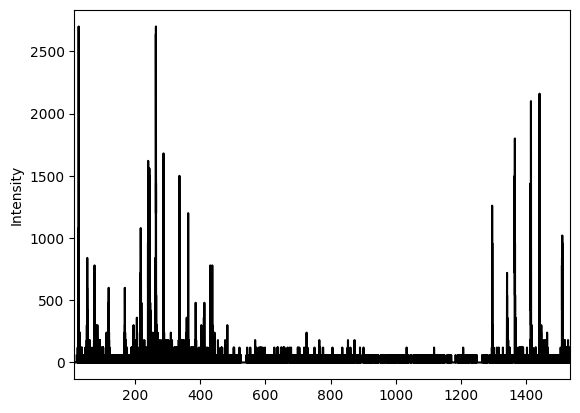

In [19]:
plot_intensity(seq,dt=1/60)

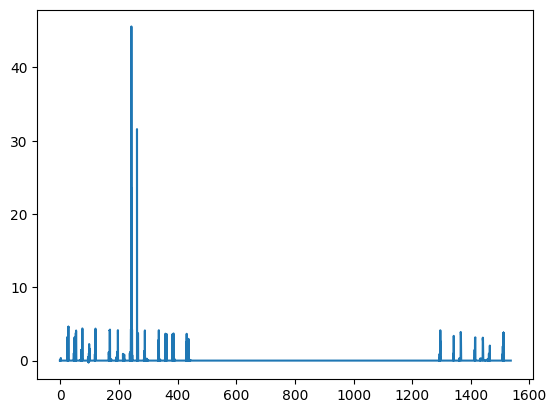

In [7]:
plt.plot(ts_time, ts)

In [8]:
ts_time.shape, ts.shape
ts_time_filtered = ts_time[ts > 2]
print(ts_time_filtered)

tensor([  23.8500,   23.8667,   23.8833,   26.5167,   26.5333,   26.5500,
          26.5667,   26.5833,   26.6000,   26.6167,   26.6333,   26.6500,
          26.6667,   26.6833,   26.7000,   26.7167,   26.7333,   26.7500,
          26.7667,   26.7833,   26.8000,   26.8167,   26.8333,   26.8500,
          26.8667,   26.8833,   26.9000,   26.9167,   26.9333,   26.9500,
          26.9667,   26.9833,   27.0000,   27.0167,   27.0333,   27.0500,
          27.0667,   27.0833,   47.7167,   47.7333,   47.7500,   52.1667,
          52.1833,   52.2000,   52.2167,   52.2333,   52.2500,   52.2667,
          52.2833,   52.3000,   52.3167,   52.3333,   52.3500,   52.3667,
          52.3833,   52.4000,   52.4167,   52.4333,   52.4500,   52.4667,
          52.4833,   52.5000,   52.5167,   52.5333,   52.5500,   52.5667,
          52.5833,   52.6000,   52.6167,   52.6333,   52.6500,   52.6667,
          52.6833,   52.7000,   52.7167,   52.7333,   52.7500,   52.7667,
          52.7833,   52.8000,   52.816

In [9]:
t_arr = seq.arrival_times.cpu().numpy()
T0 =0 
T = float(seq.arrival_times.max())
dt =1/60
edges = np.arange(T0, T + dt, dt)

counts, _ = np.histogram(t_arr, bins=edges)
lam = counts / dt

In [10]:
lam.max()

np.float64(2820.0)

In [11]:
indices = np.nonzero(lam > 500)[0]
indices/60

array([  25.7       ,   25.71666667,   25.75      ,   25.76666667,
         25.78333333,   25.81666667,   25.83333333,   25.85      ,
         25.86666667,   25.88333333,   25.9       ,   25.91666667,
         25.93333333,   25.95      ,   25.96666667,   25.98333333,
         26.        ,   26.01666667,   26.03333333,   26.05      ,
         26.06666667,   26.08333333,   26.1       ,   26.11666667,
         26.13333333,   26.15      ,   26.16666667,   26.18333333,
         26.2       ,   26.21666667,   26.28333333,   26.31666667,
         51.96666667,   52.55      ,   52.63333333,   52.66666667,
         52.85      ,   74.33333333,   74.36666667,   74.5       ,
         74.63333333,   74.93333333,   74.95      ,   75.        ,
        118.41666667,  118.58333333,  216.61666667,  216.73333333,
        216.8       ,  216.83333333,  216.85      ,  216.86666667,
        216.88333333,  216.9       ,  216.91666667,  216.95      ,
        216.96666667,  216.98333333,  217.03333333,  217.05   

In [12]:
ts_count, edges = np.histogram(t_arr, bins=ts_time)
ts_ = (ts[1:]+ts[:-1])/2
ts_time_ = (ts_time[1:] + ts_time[:-1]) / 2

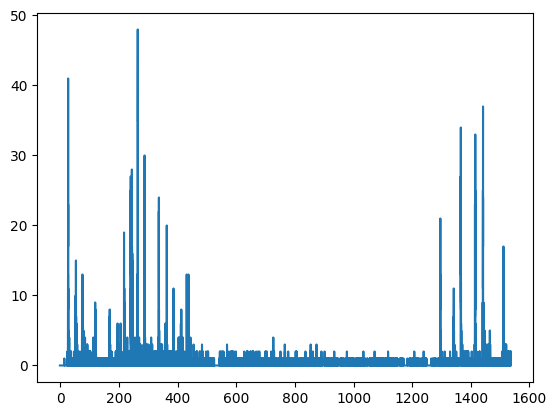

In [13]:
plt.plot(ts_time_, ts_count)
# plt.plot(ts_time, ts)

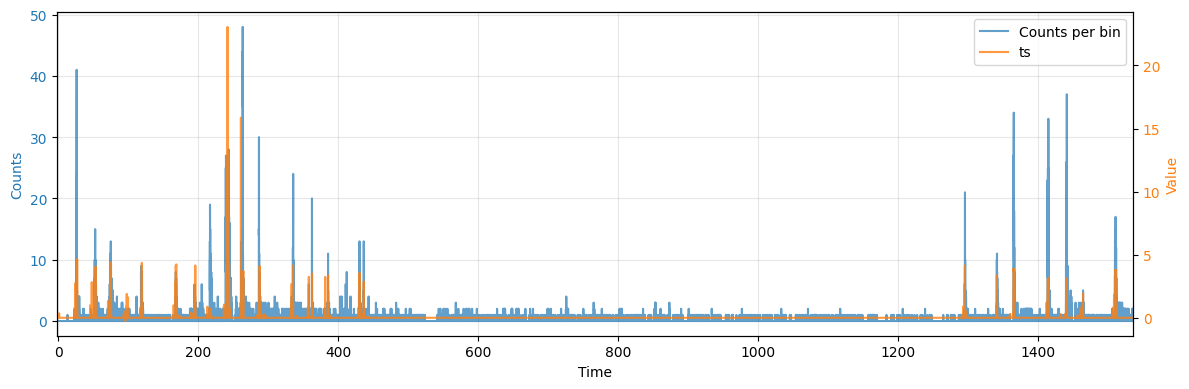

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 4))
l1 = ax1.plot(ts_time[1:].numpy(), ts_count, label="Counts per bin", color="C0", alpha=0.7)
ax1.set_xlabel("Time")
ax1.set_ylabel("Counts", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.set_xlim(ts_time.min().item(), ts_time.max().item())
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
l2 = ax2.plot(ts_time_.numpy(), ts_.numpy(), label="ts", color="C1", alpha=0.8)
ax2.set_ylabel("Value", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

lines = l1 + l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")
fig.tight_layout()

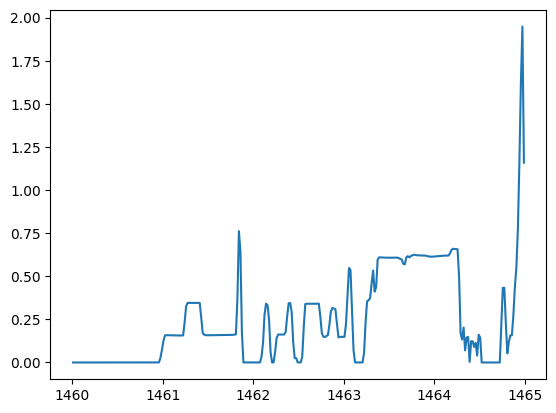

In [15]:
mask  = (ts_time_ >= 1460) & (ts_time_ <= 1465)
plt.plot(ts_time_[mask], ts_[mask])

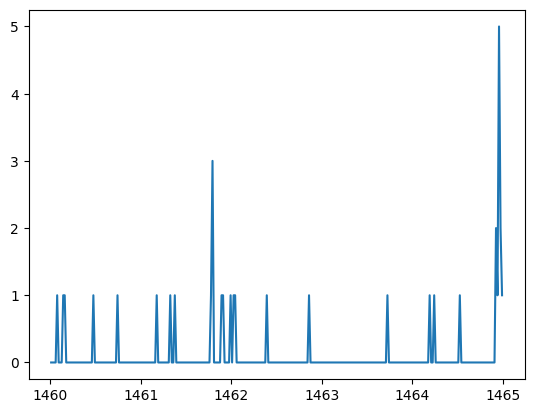

In [16]:
plt.plot(ts_time_[mask], ts_count[mask])


In [17]:
ts_[mask].sum() ,ts_count[mask].sum()

(tensor(73.3943), np.int64(34))